# SkinVision AI MobileNetV2

**Judul proyek:** Klasifikasi Kondisi Kulit Wajah Menggunakan Artificial Intelligence dan Computer Vision Berbasis MobileNetV2

Notebook ini digunakan untuk melatih model klasifikasi gambar kulit menggunakan **Transfer Learning MobileNetV2**.

Dataset yang digunakan berisi 7 class:

1. Acne
2. Blackheads
3. Dark Spots
4. Dry Skin
5. Normal Skin
6. Oily Skin
7. Wrinkles


## BAB 1. Pendahuluan

Aplikasi SkinVision AI dibuat untuk membantu pengguna melakukan klasifikasi awal kondisi kulit berdasarkan gambar. Sistem ini memakai Artificial Intelligence dan Computer Vision. Model menerima input gambar kulit, melakukan preprocessing, lalu menghasilkan prediksi class beserta tingkat confidence.

Aplikasi ini hanya digunakan untuk demo proyek UAS. Hasil prediksi tidak menggantikan pemeriksaan dokter.

Tujuan proyek:

- Membuat model AI untuk klasifikasi gambar kulit.
- Menggunakan Transfer Learning MobileNetV2 agar model lebih kuat dibanding CNN sederhana.
- Menampilkan hasil prediksi, confidence score, dan status awal pada aplikasi web.

## BAB 2. Setup Environment dan Import Library

In [ ]:
import os
import zipfile
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## BAB 3. Upload dan Ekstraksi Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print("File yang diupload:", zip_name)

Saving archive (4).zip to archive (4) (1).zip
File yang diupload: archive (4) (1).zip


In [ ]:
extract_path = "/content/skinvision_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak ke:", extract_path)

for root, dirs, files_ in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        dirs[:] = []

Dataset berhasil diekstrak ke: /content/skinvision_dataset
skinvision_dataset/
  skin_dataset/
    train/
    val/


### Deteksi Otomatis Folder Dataset

In [ ]:
def find_dataset_dir(base_path):
    expected = {"Acne", "Blackheads", "Dark Spots", "Dry Skin", "Normal Skin", "Oily Skin", "Wrinkles"}
    candidates = []

    for root, dirs, files_ in os.walk(base_path):
        dir_set = set(dirs)
        score = len(expected.intersection(dir_set))
        if score >= 3:
            candidates.append((score, root, dirs))

    if not candidates:
        raise FileNotFoundError("Folder dataset tidak ditemukan. Pastikan ZIP berisi folder class gambar.")

    candidates.sort(reverse=True, key=lambda x: x[0])
    return candidates[0][1]

dataset_dir = find_dataset_dir(extract_path)
print("Folder dataset yang digunakan:", dataset_dir)
print("Class yang ditemukan:", os.listdir(dataset_dir))

Folder dataset yang digunakan: /content/skinvision_dataset/skin_dataset/train
Class yang ditemukan: ['Dry Skin', 'Dark Spots', 'Oily Skin', 'Blackheads', 'Acne', 'Normal Skin', 'Wrinkles']


## BAB 4. Eksplorasi Dataset

Bagian ini menampilkan jumlah gambar pada setiap class. Ini penting untuk melihat apakah dataset seimbang atau tidak.

In [ ]:
class_counts = []

for class_name in sorted(os.listdir(dataset_dir)):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        class_counts.append({"class": class_name, "count": len(image_files)})

count_df = pd.DataFrame(class_counts)
count_df

,class,count
0,Acne,106
1,Blackheads,90
2,Dark Spots,98
3,Dry Skin,71
4,Normal Skin,92
5,Oily Skin,103
6,Wrinkles,141


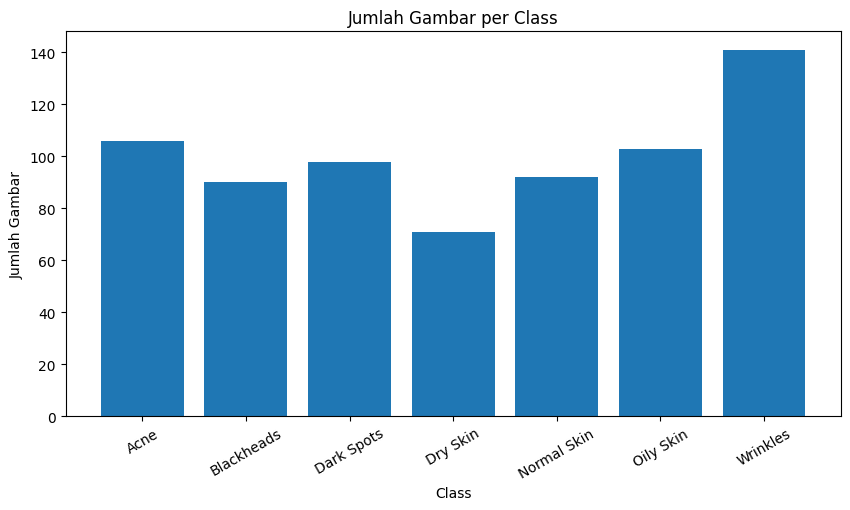

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(count_df["class"], count_df["count"])
plt.title("Jumlah Gambar per Class")
plt.xlabel("Class")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=30)
plt.show()

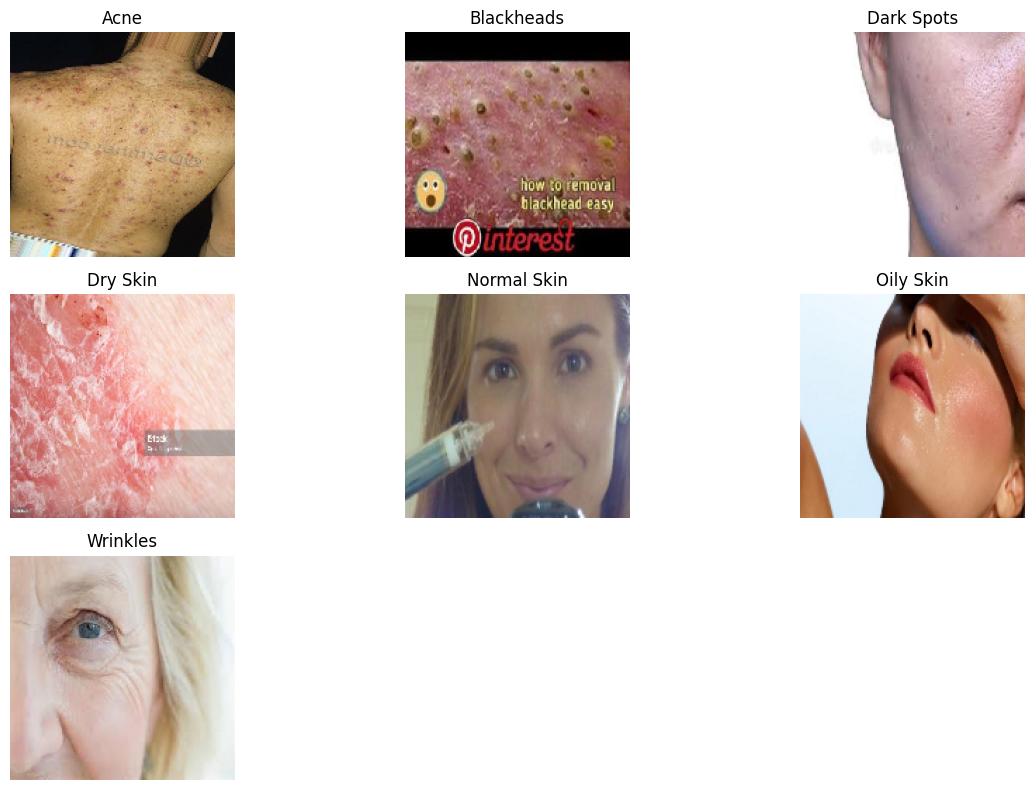

In [ ]:
plt.figure(figsize=(12, 8))

sample_index = 1
for class_name in sorted(os.listdir(dataset_dir)):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if image_files:
            img_path = os.path.join(class_path, image_files[0])
            img = image.load_img(img_path, target_size=(160, 160))
            plt.subplot(3, 3, sample_index)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
            sample_index += 1

plt.tight_layout()
plt.show()

## BAB 5. Preprocessing dan Augmentasi Data

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

class_names = list(train_generator.class_indices.keys())
num_classes = train_generator.num_classes

print("Class index:", train_generator.class_indices)
print("Jumlah class:", num_classes)
print("Nama class:", class_names)

Found 563 images belonging to 7 classes.
Found 138 images belonging to 7 classes.
Class index: {'Acne': 0, 'Blackheads': 1, 'Dark Spots': 2, 'Dry Skin': 3, 'Normal Skin': 4, 'Oily Skin': 5, 'Wrinkles': 6}
Jumlah class: 7
Nama class: ['Acne', 'Blackheads', 'Dark Spots', 'Dry Skin', 'Normal Skin', 'Oily Skin', 'Wrinkles']


## BAB 6. Pembuatan Model MobileNetV2

Bagian ini menggunakan Transfer Learning.

MobileNetV2 dipakai sebagai model dasar. Layer awal MobileNetV2 dibekukan terlebih dahulu agar training lebih stabil.

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,255 (10.00 MB)

 Trainable params: 362,503 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

### Training Tahap 1

Tahap ini melatih layer tambahan di atas MobileNetV2.

In [ ]:
checkpoint = ModelCheckpoint(
    "skin_disease_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=0.000001,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.1757 - loss: 2.9021
Epoch 1: val_accuracy improved from None to 0.15942, saving model to skin_disease_model.h5



Epoch 1: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.1687 - loss: 2.8262 - val_accuracy: 0.1594 - val_loss: 1.9890 - learning_rate: 1.0000e-04
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.1989 - loss: 2.5194
Epoch 2: val_accuracy improved from 0.15942 to 0.31884, saving model to skin_disease_model.h5



Epoch 2: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.2256 - loss: 2.4365 - val_accuracy: 0.3188 - val_loss: 1.8601 - learning_rate: 1.0000e-04
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.2801 - loss: 2.1556
Epoch 3: val_accuracy improved from 0.31884 to 0.34058, saving model to skin_disease_model.h5



Epoch 3: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.3002 - loss: 2.0791 - val_accuracy: 0.3406 - val_loss: 1.7589 - learning_rate: 1.0000e-04
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.3616 - loss: 1.9452
Epoch 4: val_accuracy improved from 0.34058 to 0.38406, saving model to skin_disease_model.h5



Epoch 4: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - accuracy: 0.3837 - loss: 1.8257 - val_accuracy: 0.3841 - val_loss: 1.6837 - learning_rate: 1.0000e-04
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.4145 - loss: 1.6907
Epoch 5: val_accuracy improved from 0.38406 to 0.40580, saving model to skin_disease_model.h5


...


Epoch 7: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 0.4725 - loss: 1.6040 - val_accuracy: 0.4565 - val_loss: 1.5704 - learning_rate: 1.0000e-04
Epoch 8/30
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5287 - loss: 1.3590
Epoch 8: val_accuracy did not improve from 0.45652
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step - accuracy: 0.4973 - loss: 1.4442 - val_accuracy: 0.4565 - val_loss: 1.5329 - learning_rate: 1.0000e-04
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.4993 - loss: 1.4214
Epoch 9: val_accuracy did not improve from 0.45652
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 290ms/step - accuracy: 0.5506 - loss: 1.3112 - val_accuracy: 0.4565 - val_loss: 1.4959 - learning_rate: 1.0000e-04
Epoch 10/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.5478 - loss: 1.3518
Epoch 10: val_accuracy improved from 0.45652 to 0.49275, saving model to skin_disease_model.h5



Epoch 10: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 287ms/step - accuracy: 0.5417 - loss: 1.3692 - val_accuracy: 0.4928 - val_loss: 1.4760 - learning_rate: 1.0000e-04
Epoch 11/30
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.5531 - loss: 1.2614
Epoch 11: val_accuracy did not improve from 0.49275
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.5524 - loss: 1.2500 - val_accuracy: 0.4928 - val_loss: 1.4805 - learning_rate: 1.0000e-04
Epoch 12/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6144 - loss: 1.0996
Epoch 12: val_accuracy did not improve from 0.49275
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 245ms/step - accuracy: 0.5933 - loss: 1.2224 - val_accuracy: 0.4928 - val_loss: 1.4483 - learning_rate: 1.0000e-04
Epoch 13/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.5696 - loss: 1.1580
Epoch 13: val_accuracy improved from 0.49275 to 0.51449, saving model to skin_disease_model.h5



Epoch 13: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.5666 - loss: 1.1961 - val_accuracy: 0.5145 - val_loss: 1.4395 - learning_rate: 1.0000e-04
Epoch 14/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.6074 - loss: 1.1541
Epoch 14: val_accuracy did not improve from 0.51449
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step - accuracy: 0.6146 - loss: 1.1435 - val_accuracy: 0.5145 - val_loss: 1.4117 - learning_rate: 1.0000e-04
Epoch 15/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.6275 - loss: 1.0982
Epoch 15: val_accuracy did not improve from 0.51449
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 286ms/step - accuracy: 0.6110 - loss: 1.1153 - val_accuracy: 0.4928 - val_loss: 1.4086 - learning_rate: 1.0000e-04
Epoch 16/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.6762 - loss: 0.9517
Epoch 16: val_accuracy improved from 0.51449 to 0.52174, saving model to skin_disease_model.h5



Epoch 16: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 297ms/step - accuracy: 0.6607 - loss: 0.9920 - val_accuracy: 0.5217 - val_loss: 1.4015 - learning_rate: 1.0000e-04
Epoch 17/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6463 - loss: 1.0420
Epoch 17: val_accuracy did not improve from 0.52174
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 241ms/step - accuracy: 0.6572 - loss: 0.9963 - val_accuracy: 0.5217 - val_loss: 1.4219 - learning_rate: 1.0000e-04
Epoch 18/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.6612 - loss: 0.9943
Epoch 18: val_accuracy improved from 0.52174 to 0.55072, saving model to skin_disease_model.h5



Epoch 18: finished saving model to skin_disease_model.h5
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 284ms/step - accuracy: 0.6643 - loss: 1.0123 - val_accuracy: 0.5507 - val_loss: 1.4124 - learning_rate: 1.0000e-04
Epoch 19/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.6216 - loss: 1.1333
Epoch 19: val_accuracy did not improve from 0.55072

Epoch 19: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.6572 - loss: 1.0101 - val_accuracy: 0.5290 - val_loss: 1.4718 - learning_rate: 1.0000e-04
Epoch 20/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.6689 - loss: 0.9653
Epoch 20: val_accuracy did not improve from 0.55072
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.6519 - loss: 0.9662 - val_accuracy: 0.5290 - val_loss: 1.4518 - learning_rate: 2.0000e-05
Epoch 21/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.6424 - loss: 1.0029
Epoch 21: val_accuracy did not improve from 0.55072
36/36 ━━

### Fine Tuning

Fine tuning melatih beberapa layer terakhir MobileNetV2 agar lebih sesuai dengan dataset kulit.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.4205 - loss: 1.6779
Epoch 1: val_accuracy did not improve from 0.55072
36/36 ━━━━━━━━━━━━━━━━━━━━ 51s 793ms/step - accuracy: 0.4227 - loss: 1.6731 - val_accuracy: 0.5290 - val_loss: 1.4145 - learning_rate: 1.0000e-05
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.4648 - loss: 1.6792
Epoch 2: val_accuracy did not improve from 0.55072
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.4689 - loss: 1.6068 - val_accuracy: 0.5217 - val_loss: 1.4618 - learning_rate: 1.0000e-05
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.4783 - loss: 1.5847
Epoch 3: val_accuracy did not improve from 0.55072

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - accuracy: 0.4707 - loss: 1.5912 - val_accuracy: 0.5072 - val_loss: 1.5345 - learning_rate: 1.0000e-05
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.4651 - 

## BAB 7. Evaluasi Model

Bagian ini mengecek akurasi model pada data validation.

In [ ]:
loss, accuracy = model.evaluate(val_generator)

print("Validation Loss:", round(loss, 4))
print("Validation Accuracy:", round(accuracy * 100, 2), "%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5290 - loss: 1.4145
Validation Loss: 1.4145
Validation Accuracy: 52.9 %


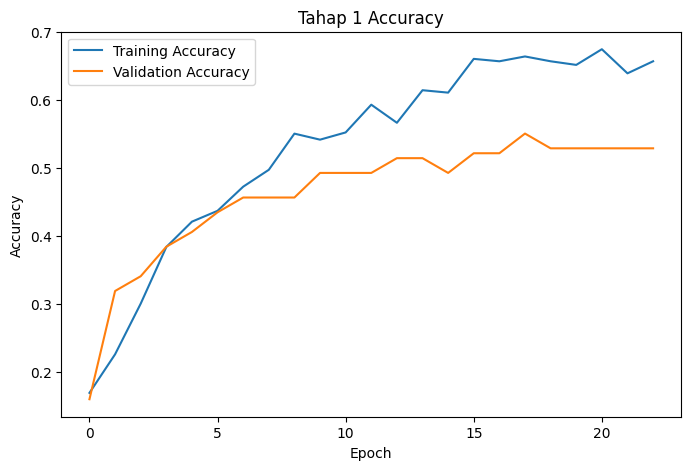

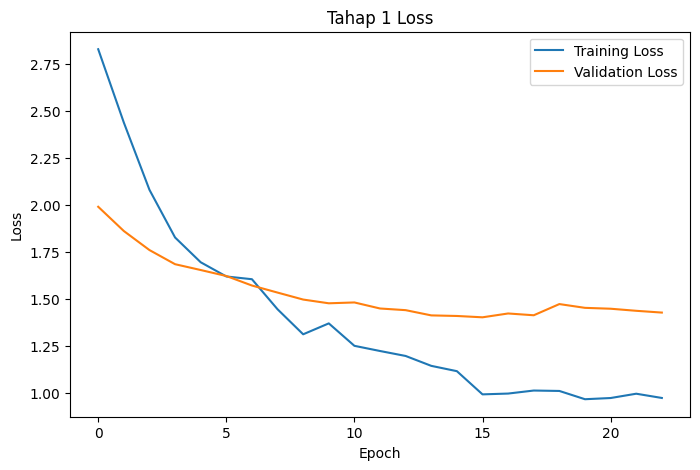

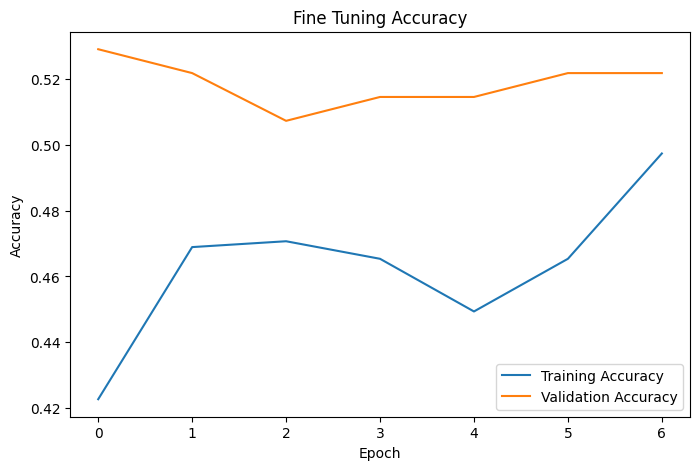

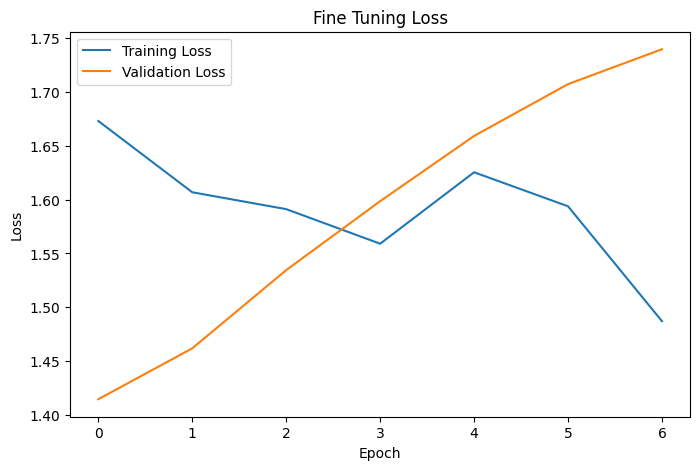

In [ ]:
def plot_history(history_obj, title_prefix="Training"):
    plt.figure(figsize=(8, 5))
    plt.plot(history_obj.history["accuracy"], label="Training Accuracy")
    plt.plot(history_obj.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_obj.history["loss"], label="Training Loss")
    plt.plot(history_obj.history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history, "Tahap 1")
plot_history(fine_tune_history, "Fine Tuning")

### Confusion Matrix dan Classification Report

Bagian ini menunjukkan class mana yang sering benar dan class mana yang sering tertukar.

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 668ms/step
              precision    recall  f1-score   support

        Acne       0.60      0.57      0.59        21
  Blackheads       0.67      0.78      0.72        18
  Dark Spots       0.64      0.84      0.73        19
    Dry Skin       0.50      0.14      0.22        14
 Normal Skin       0.27      0.17      0.21        18
   Oily Skin       0.39      0.55      0.46        20
    Wrinkles       0.52      0.54      0.53        28

    accuracy                           0.53       138
   macro avg       0.51      0.51      0.49       138
weighted avg       0.51      0.53      0.51       138



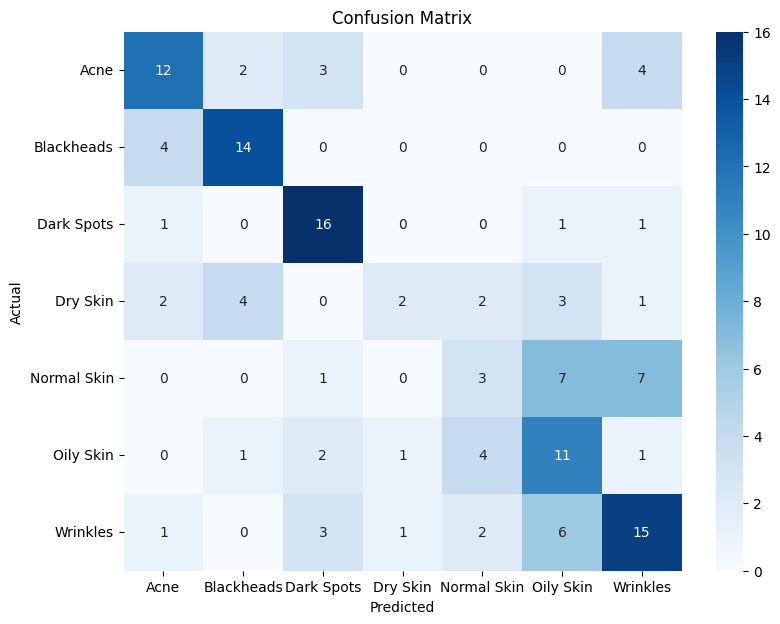

In [ ]:
val_generator.reset()
y_pred_prob = model.predict(val_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Uji Prediksi Satu Gambar

Bagian ini digunakan untuk demo prediksi satu gambar.

Upload satu gambar kulit dengan format JPG, JPEG, atau PNG.

Saving berminyak__-42-_jpg.rf.c88d2c426bafe62c14208a639e15006d.jpg to berminyak__-42-_jpg.rf.c88d2c426bafe62c14208a639e15006d.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


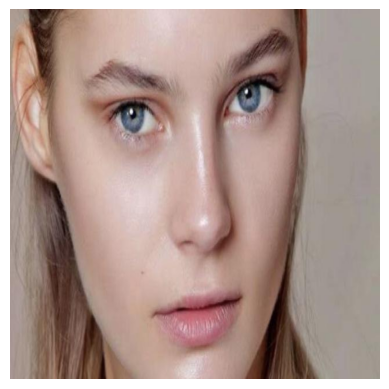

Top 3 Prediksi:
Oily Skin : 80.23 %
Normal Skin : 9.0 %
Dark Spots : 6.24 %

Hasil utama: Oily Skin
Confidence: 80.23 %

Status: Prediksi cukup kuat


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_skin_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0]
    top_3_indices = prediction.argsort()[-3:][::-1]

    plt.imshow(image.load_img(img_path))
    plt.axis("off")
    plt.show()

    print("Top 3 Prediksi:")
    for i in top_3_indices:
        print(class_names[i], ":", round(prediction[i] * 100, 2), "%")

    best_index = top_3_indices[0]
    predicted_class = class_names[best_index]
    confidence = prediction[best_index] * 100

    print("")
    print("Hasil utama:", predicted_class)
    print("Confidence:", round(confidence, 2), "%")

    if confidence < 60:
        print("")
        print("Status: Model belum yakin")
        print("Saran: Gunakan gambar yang lebih jelas, terang, dan fokus pada area kulit.")
    else:
        print("")
        print("Status: Prediksi cukup kuat")

    return predicted_class, confidence

uploaded_test = files.upload()

if len(uploaded_test) > 0:
    test_img_path = list(uploaded_test.keys())[0]
    result = predict_skin_image(test_img_path)
else:
    print("Tidak ada gambar yang diupload.")

## BAB 8. Simpan Model

In [ ]:
model.save("skin_disease_model.h5")

with open("class_names.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")

print("Model dan class names berhasil disimpan.")
print("File model: skin_disease_Model.h5")
print("File label: class_names.txt")
print("Class names:", class_names)

Model dan class names berhasil disimpan.
File model: skin_disease_Model.h5
File label: class_names.txt
Class names: ['Acne', 'Blackheads', 'Dark Spots', 'Dry Skin', 'Normal Skin', 'Oily Skin', 'Wrinkles']


In [ ]:
from google.colab import files

files.download("skin_disease_model.h5")
files.download("class_names.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Kesimpulan

Notebook ini menghasilkan model klasifikasi gambar kulit berbasis MobileNetV2. Model ini dapat digunakan pada web SkinVision AI untuk menampilkan prediksi kondisi kulit dan tingkat confidence.

Jika akurasi belum mencapai target, perbaikan dapat dilakukan dengan:

- Menambah jumlah gambar pada class yang sedikit.
- Membersihkan gambar yang salah label.
- Menggunakan gambar dengan pencahayaan lebih konsisten.
- Mengurangi class yang terlalu mirip.
- Melakukan fine tuning dengan jumlah layer yang berbeda.